# 한국은행(BOK) 경제통계시스템 데이터 수집

이 노트북은 한국은행 ECOS API를 통해 경제지표 데이터를 다운로드하고 MySQL 데이터베이스에 저장합니다.

## 주요 기능
- 한국은행 ECOS API를 통한 경제지표 데이터 수집
- SeriesSpec 기반 데이터 요청
- MoM, YoY 변화율 계산
- MySQL 데이터베이스 저장
- 데이터 검증 및 결과 확인

## 1. 환경 설정

In [1]:
import os
import sys
import importlib
import pandas as pd
import numpy as np
import warnings
from datetime import datetime
from typing import Dict, List

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

## 2. API 인증 설정

In [2]:
# 한국은행 ECOS API 키 설정
API_KEY = "O6FJIBYZCWZF9ZFHL6F9"

## 3. 작업 경로 설정 및 모듈 로드

In [3]:
# BOK 모듈 경로 설정 (필요시 수정)
BOK_DIR = None
# 예시: BOK_DIR = r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\지표상회\BOK"

if BOK_DIR:
    if BOK_DIR not in sys.path:
        sys.path.insert(0, BOK_DIR)
    os.chdir(BOK_DIR)

print("현재 작업 폴더:", os.getcwd())
print("sys.path[0]:", sys.path[0])

현재 작업 폴더: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\ODP\BOK
sys.path[0]: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\ODP\BOK


In [4]:
# 모듈 import 및 reload
import economy_index_codes
import bok_econ_downloader

importlib.reload(economy_index_codes)
importlib.reload(bok_econ_downloader)

print("모듈 로드 완료")

모듈 로드 완료


## 4. 데이터베이스 연결 설정

In [5]:
# DATA.config를 사용하여 데이터베이스 연결 설정
from DATA.config import get_db_info, get_engine

# DB 정보 가져오기
db_info = get_db_info()
print(f"데이터베이스 연결 정보:")
print(f"  - Host: {db_info['host']}")
print(f"  - Port: {db_info['port']}")
print(f"  - Database: {db_info['database']}")
print(f"  - User: {db_info['user']}")

# SQLAlchemy 엔진 생성
engine = get_engine(db_info)

print("\n데이터베이스 연결 설정 완료")

데이터베이스 연결 정보:
  - Host: 192.168.0.230
  - Port: 3307
  - Database: investar
  - User: stox7412

데이터베이스 연결 설정 완료


## 5. SeriesSpec 생성

In [6]:
# ECOS_INDEX_MAP 불러오기
ECOS_INDEX_MAP = economy_index_codes.ECOS_INDEX_MAP

print(f"총 {len(ECOS_INDEX_MAP)}개의 경제지표 정의 로드")
print("\n지표 목록 (처음 10개):")
for i, (index_name, index_info) in enumerate(list(ECOS_INDEX_MAP.items())[:10], 1):
    print(f"{i:2d}. {index_name:30s} - {index_info['category']:15s} (stat_code: {index_info['stat_code']})")

총 66개의 경제지표 정의 로드

지표 목록 (처음 10개):
 1. M2광의통화                         - 통화량             (stat_code: 101Y005)
 2. 은행대출금_기업                       - 대출금             (stat_code: 901Y054)
 3. 은행대출금_가계                       - 대출금             (stat_code: 901Y054)
 4. 예금은행_수신금리(신규)                  - 여수신금리           (stat_code: 121Y002)
 5. 예금은행_수신금리(잔액)                  - 여수신금리           (stat_code: 121Y015)
 6. 예금은행_대출금리(신규)                  - 여수신금리           (stat_code: 121Y006)
 7. 전산업생산지수                        - 생산              (stat_code: 901Y033)
 8. 제조업생산지수_계절조정                   - 생산              (stat_code: 901Y032)
 9. 제조업출하지수_계절조정                   - 생산              (stat_code: 901Y032)
10. 제조업재고지수                        - 생산              (stat_code: 901Y032)


In [7]:
# SeriesSpec 생성
specs = bok_econ_downloader.build_specs_from_index_map(
    index_map=ECOS_INDEX_MAP,
    default_cycle="M",
    default_start="201001",  # 2010년 1월부터
    default_end="202512",    # 2025년 12월까지
    lang="kr"
)

print(f"\n생성된 SeriesSpec: {len(specs)}개")
print("\nSeriesSpec 샘플 (처음 3개):")
for i, spec in enumerate(specs[:3], 1):
    print(f"\n{i}. {spec.name}")
    print(f"   stat_code: {spec.stat_code}")
    print(f"   items: {spec.items}")
    print(f"   cycle: {spec.cycle}")
    print(f"   period: {spec.start} ~ {spec.end}")


생성된 SeriesSpec: 66개

SeriesSpec 샘플 (처음 3개):

1. M2광의통화
   stat_code: 101Y005
   items: ('BBGS00',)
   cycle: M
   period: 201001 ~ 202512

2. 은행대출금_기업
   stat_code: 901Y054
   items: ('MO3AA', 'AB')
   cycle: M
   period: 201001 ~ 202512

3. 은행대출금_가계
   stat_code: 901Y054
   items: ('MO3AB', 'AB')
   cycle: M
   period: 201001 ~ 202512


## 6. 데이터 수집 실행

In [8]:
# 데이터 수집 실행
print("=" * 80)
print("데이터 수집 시작")
print("=" * 80)
print(f"수집 대상: {len(specs)}개 지표")
print(f"API KEY: {API_KEY[:10]}...")
print()

# fetch_economic_indicators는 Dict[str, DataFrame]을 반환
results_dict = bok_econ_downloader.fetch_economic_indicators(
    api_key=API_KEY,
    specs=specs,
    fail_fast=False
)

# 결과를 long format DataFrame으로 변환
# BOKClient.fetch_series 반환 형식: Date, value, name, stat_code, cycle, item1~4
raw_data = []
for name, df in results_dict.items():
    if df is not None and not df.empty:
        raw_data.append(df)

raw_df = pd.concat(raw_data, ignore_index=True) if raw_data else pd.DataFrame()

print("\n" + "=" * 80)
print("데이터 수집 완료")
print("=" * 80)
print(f"수집된 데이터 건수: {len(raw_df):,}")
print(f"데이터 형태: {raw_df.shape}")
if not raw_df.empty:
    print(f"컬럼: {list(raw_df.columns)}")

데이터 수집 시작
수집 대상: 66개 지표
API KEY: O6FJIBYZCW...

[FAIL] M2광의통화: ECOS API error: INFO-200 | 해당하는 데이터가 없습니다.

데이터 수집 완료
수집된 데이터 건수: 12,240
데이터 형태: (12240, 9)
컬럼: ['Date', 'value', 'name', 'stat_code', 'cycle', 'item1', 'item2', 'item3', 'item4']


## 7. 데이터 전처리

In [9]:
# 데이터 전처리 및 변화율 계산
def compute_changes(df):
    """
    MoM, YoY 변화율 계산
    입력: Date, value, name, stat_code, cycle 등을 포함한 DataFrame
    출력: MoM, YoY 컬럼이 추가된 DataFrame
    """
    if df.empty:
        return df
    
    df = df.copy()
    df = df.sort_values(['name', 'Date']).reset_index(drop=True)
    
    # 그룹별로 변화율 계산
    def calc_changes(group):
        group = group.copy()
        # MoM (Month-over-Month): 전월대비
        group['MoM'] = group['value'].pct_change(periods=1)
        # YoY (Year-over-Year): 전년동기대비
        group['YoY'] = group['value'].pct_change(periods=12)
        return group
    
    df = df.groupby('name', group_keys=False).apply(calc_changes)
    
    return df

# 변화율 계산
result_df = compute_changes(raw_df)

# economy_index_codes에서 추가 정보 매핑
if not result_df.empty:
    # Index_Code, Index_Detail, Category 추가
    index_info = []
    for _, row in result_df.iterrows():
        name = row['name']
        if name in ECOS_INDEX_MAP:
            info = ECOS_INDEX_MAP[name]
            index_info.append({
                'Index_Code': info.get('index_code', name),
                'Index_Detail': info.get('detail', ''),
                'Category': info.get('category', '')
            })
        else:
            index_info.append({
                'Index_Code': name,
                'Index_Detail': '',
                'Category': ''
            })
    
    info_df = pd.DataFrame(index_info)
    result_df = pd.concat([result_df.reset_index(drop=True), info_df], axis=1)
    
    # Report_Date 추가
    result_df['Report_Date'] = pd.Timestamp.today().strftime('%Y-%m-%d')

# 컬럼 순서 정리
final_columns = [
    'Index_Code',
    'name',  # Index_Name 대신 name 사용
    'Index_Detail',
    'Category',
    'stat_code',
    'cycle',  # freq 대신 cycle 사용
    'Date',
    'value',  # Value 대신 value 사용
    'MoM',
    'YoY',
    'Report_Date'
]

# 존재하는 컬럼만 선택
available_columns = [col for col in final_columns if col in result_df.columns]
result_df = result_df[available_columns]

# 컬럼명 정규화 (DB 저장용)
result_df = result_df.rename(columns={
    'name': 'Index_Name',
    'value': 'Value',
    'cycle': 'freq'
})

print("데이터 전처리 완료")
print(f"최종 데이터 건수: {len(result_df):,}")
print(f"\n컬럼 목록:")
for col in result_df.columns:
    print(f"  - {col}")

데이터 전처리 완료
최종 데이터 건수: 12,240

컬럼 목록:
  - Index_Code
  - Index_Name
  - Index_Detail
  - Category
  - stat_code
  - freq
  - Date
  - Value
  - MoM
  - YoY
  - Report_Date


## 8. 데이터 미리보기

In [10]:
print("=" * 80)
print("데이터 미리보기")
print("=" * 80)
display(result_df.head(20))

데이터 미리보기


,Index_Code,Index_Name,Index_Detail,Category,stat_code,freq,Date,Value,MoM,YoY,Report_Date
0,BSI,BSI,,심리지표,512Y007,M,2010-01-31,89.0,NaN,NaN,2026-02-03
1,BSI,BSI,,심리지표,512Y007,M,2010-02-28,89.0,0.000000,NaN,2026-02-03
2,BSI,BSI,,심리지표,512Y007,M,2010-03-31,89.0,0.000000,NaN,2026-02-03
3,BSI,BSI,,심리지표,512Y007,M,2010-04-30,94.0,0.056180,NaN,2026-02-03
4,BSI,BSI,,심리지표,512Y007,M,2010-05-31,95.0,0.010638,NaN,2026-02-03
5,BSI,BSI,,심리지표,512Y007,M,2010-06-30,94.0,-0.010526,NaN,2026-02-03
6,BSI,BSI,,심리지표,512Y007,M,2010-07-31,93.0,-0.010638,NaN,2026-02-03
7,BSI,BSI,,심리지표,512Y007,M,2010-08-31,88.0,-0.053763,NaN,2026-02-03
8,BSI,BSI,,심리지표,512Y007,M,2010-09-30,88.0,0.000000,NaN,2026-02-03
9,BSI,BSI,,심리지표,512Y007,M,2010-10-31,89.0,0.011364,NaN,2026-02-03


## 9. 데이터베이스 저장

In [11]:
# 저장 함수 정의
def save_to_database(df, engine, table_name, if_exists='replace'):
    # NaN을 None으로 변환 (MySQL NULL)
    df_to_save = df.copy()
    df_to_save = df_to_save.where(pd.notna(df_to_save), None)
    
    # 데이터베이스에 저장
    df_to_save.to_sql(
        name=table_name,
        con=engine,
        if_exists=if_exists,
        index=False,
        chunksize=1000
    )
    
    print(f"✓ {len(df_to_save):,}개 레코드를 '{table_name}' 테이블에 저장 완료")

# 저장 실행
TABLE_NAME = "bok_economic_indicators"

print("=" * 80)
print(f"데이터베이스 저장 시작: {TABLE_NAME}")
print("=" * 80 + "\n")

save_to_database(result_df, engine, TABLE_NAME, if_exists='replace')

print("\n" + "=" * 80)
print("데이터베이스 저장 완료")
print("=" * 80)

데이터베이스 저장 시작: bok_economic_indicators

✓ 12,240개 레코드를 'bok_economic_indicators' 테이블에 저장 완료

데이터베이스 저장 완료


In [12]:
# 데이터 품질 확인
print("\n" + "=" * 80)
print("데이터 품질 체크")
print("=" * 80)

print("\n1. 결측치 현황:")
missing_counts = result_df.isnull().sum()
missing_pct = (result_df.isnull().sum() / len(result_df) * 100).round(2)
missing_df = pd.DataFrame({
    '결측치 개수': missing_counts,
    '결측치 비율(%)': missing_pct
})
print(missing_df[missing_df['결측치 개수'] > 0])

print("\n2. 데이터 타입:")
print(result_df.dtypes)

print("\n3. Value 컬럼 기술통계:")
print(result_df['Value'].describe())


데이터 품질 체크

1. 결측치 현황:
     결측치 개수  결측치 비율(%)
MoM      65       0.53
YoY     780       6.37

2. 데이터 타입:
Index_Code              object
Index_Name              object
Index_Detail            object
Category                object
stat_code               object
freq                    object
Date            datetime64[ns]
Value                  float64
MoM                    float64
YoY                    float64
Report_Date             object
dtype: object

3. Value 컬럼 기술통계:
count    1.224000e+04
mean     2.447038e+09
std      2.173469e+10
min     -8.928200e+03
25%      7.400000e+01
50%      1.005850e+02
75%      1.925125e+02
max      5.295564e+11
Name: Value, dtype: float64


## 10. 데이터베이스 저장 확인

In [13]:
# DB에서 직접 조회하여 확인
query = f"""
SELECT 
    COUNT(*) as total_records,
    COUNT(DISTINCT Index_Code) as unique_indices,
    COUNT(DISTINCT Index_Name) as unique_index_names,
    MIN(Date) as start_date,
    MAX(Date) as end_date,
    MAX(Report_Date) as last_update
FROM {TABLE_NAME}
"""

db_stats = pd.read_sql(query, engine)

print("=" * 80)
print("데이터베이스 저장 현황")
print("=" * 80)
for col in db_stats.columns:
    value = db_stats[col].iloc[0]
    if isinstance(value, (int, float)):
        print(f"{col:25s}: {value:,}")
    else:
        print(f"{col:25s}: {value}")

데이터베이스 저장 현황
total_records            : 12240
unique_indices           : 65
unique_index_names       : 65
start_date               : 2010-01-31 00:00:00
end_date                 : 2025-12-31 00:00:00
last_update              : 2026-02-02


In [14]:
# 최근 데이터 확인
recent_query = f"""
SELECT *
FROM {TABLE_NAME}
ORDER BY Date DESC, Index_Code
LIMIT 20
"""

recent_data = pd.read_sql(recent_query, engine)

print("\n" + "=" * 80)
print("데이터베이스 최근 데이터")
print("=" * 80)
display(recent_data)


데이터베이스 최근 데이터


,Index_Code,Index_Name,Index_Detail,Category,stat_code,freq,Date,Value,MoM,YoY,Report_Date
0,BSI,BSI,,심리지표,512Y007,M,2025-12-31,7.100000e+01,0.014286,0.109375,2026-02-02
1,KOSPI_거래대금,KOSPI_거래대금,,주식_채권_재정,901Y014,M,2025-12-31,3.027538e+11,-0.131686,0.732924,2026-02-02
2,KOSPI_사장주식_회전률,KOSPI_사장주식_회전률,,주식_채권_재정,901Y014,M,2025-12-31,1.322000e+01,0.152572,-0.157425,2026-02-02
3,건설기성액_불변_계절조정,건설기성액_불변_계절조정,,투자,901Y104,M,2025-12-31,9.813531e+06,0.120654,-0.044488,2026-02-02
4,건설수주액,건설수주액,,투자,901Y020,M,2025-12-31,3.498593e+07,0.737123,0.186597,2026-02-02
5,경기선행지수,경기선행지수,,경기순환,901Y067,M,2025-12-31,1.240000e+02,0.008130,0.058020,2026-02-02
6,경제심리지수,경제심리지수,,심리지표,513Y001,M,2025-12-31,9.350000e+01,-0.010582,0.118421,2026-02-02
7,경제활동인구,경제활동인구,,고용,901Y027,M,2025-12-31,2.980800e+04,0.007095,0.009072,2026-02-02
8,고용률,고용률,,고용,901Y027,M,2025-12-31,6.240000e+01,-0.006369,0.001605,2026-02-02
9,구리,구리,,원자재,902Y003,M,2025-12-31,1.179096e+04,0.090541,0.323353,2026-02-02


## 11. 특정 지표 상세 조회

In [15]:
# 조회 가능한 지표 목록 출력
available_indices = pd.read_sql(
    f"SELECT DISTINCT Index_Code, Index_Name, Index_Detail FROM {TABLE_NAME} ORDER BY Index_Name",
    engine
)

print("=" * 80)
print("조회 가능한 지표 목록")
print("=" * 80)
for idx, row in available_indices.iterrows():
    print(f"{row['Index_Code']:15s} {row['Index_Name']:40s} [{row['Index_Detail']}]")

조회 가능한 지표 목록
BSI             BSI                                      []
KOSPI_거래대금      KOSPI_거래대금                               []
KOSPI_사장주식_회전률  KOSPI_사장주식_회전률                           []
건설기성액_불변_계절조정   건설기성액_불변_계절조정                            []
건설수주액           건설수주액                                    []
건축착공면적          건축착공면적                                   []
건축허가면적          건축허가면적                                   []
경기선행지수          경기선행지수                                   []
경상수지            경상수지                                     []
경제심리지수          경제심리지수                                   []
경제활동인구          경제활동인구                                   []
고용률             고용률                                      []
구리              구리                                       []
국고채(10년)        국고채(10년)                                 []
국고채(3년)         국고채(3년)                                  []
국고채(5년)         국고채(5년)                                  []
국내수요기계수주액       국내수요기계수주액  

In [17]:
# 특정 지표 선택 및 조회
selected_index_name = '국고채(10년)'  # 원하는 지표명으로 변경

detail_query = f"""
SELECT *
FROM {TABLE_NAME}
WHERE Index_Name = '{selected_index_name}'
ORDER BY Date DESC
LIMIT 100
"""

detail_data = pd.read_sql(detail_query, engine)

print("=" * 80)
print(f"지표 상세 조회: {selected_index_name}")
print("=" * 80)
if len(detail_data) > 0:
    print(f"지표 코드: {detail_data['Index_Code'].iloc[0]}")
    print(f"상세: {detail_data['Index_Detail'].iloc[0]}")
    print(f"빈도: {detail_data['freq'].iloc[0]}")
    print(f"기간: {detail_data['Date'].min()} ~ {detail_data['Date'].max()}")
    print(f"데이터 건수: {len(detail_data)}")
    print(f"\n최근 20개 데이터:")
    display(detail_data.head(20))
else:
    print("해당 지표의 데이터가 없습니다.")

지표 상세 조회: 국고채(10년)
지표 코드: 국고채(10년)
상세: 
빈도: M
기간: 2017-09-30 00:00:00 ~ 2025-12-31 00:00:00
데이터 건수: 100

최근 20개 데이터:


,Index_Code,Index_Name,Index_Detail,Category,stat_code,freq,Date,Value,MoM,YoY,Report_Date
0,국고채(10년),국고채(10년),,시장금리,721Y001,M,2025-12-31,3.366,0.036330,0.214724,2026-02-02
1,국고채(10년),국고채(10년),,시장금리,721Y001,M,2025-11-30,3.248,0.107399,0.080506,2026-02-02
2,국고채(10년),국고채(10년),,시장금리,721Y001,M,2025-10-31,2.933,0.029484,-0.044625,2026-02-02
3,국고채(10년),국고채(10년),,시장금리,721Y001,M,2025-09-30,2.849,0.012078,-0.053803,2026-02-02
4,국고채(10년),국고채(10년),,시장금리,721Y001,M,2025-08-31,2.815,-0.008803,-0.061354,2026-02-02
5,국고채(10년),국고채(10년),,시장금리,721Y001,M,2025-07-31,2.840,-0.000704,-0.104383,2026-02-02
6,국고채(10년),국고채(10년),,시장금리,721Y001,M,2025-06-30,2.842,0.048708,-0.148337,2026-02-02
7,국고채(10년),국고채(10년),,시장금리,721Y001,M,2025-05-31,2.710,0.019564,-0.231642,2026-02-02
8,국고채(10년),국고채(10년),,시장금리,721Y001,M,2025-04-30,2.658,-0.049016,-0.254836,2026-02-02
9,국고채(10년),국고채(10년),,시장금리,721Y001,M,2025-03-31,2.795,-0.012367,-0.175516,2026-02-02


## 12. 데이터 시각화

In [18]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-darkgrid')

print("시각화 준비 완료")

시각화 준비 완료


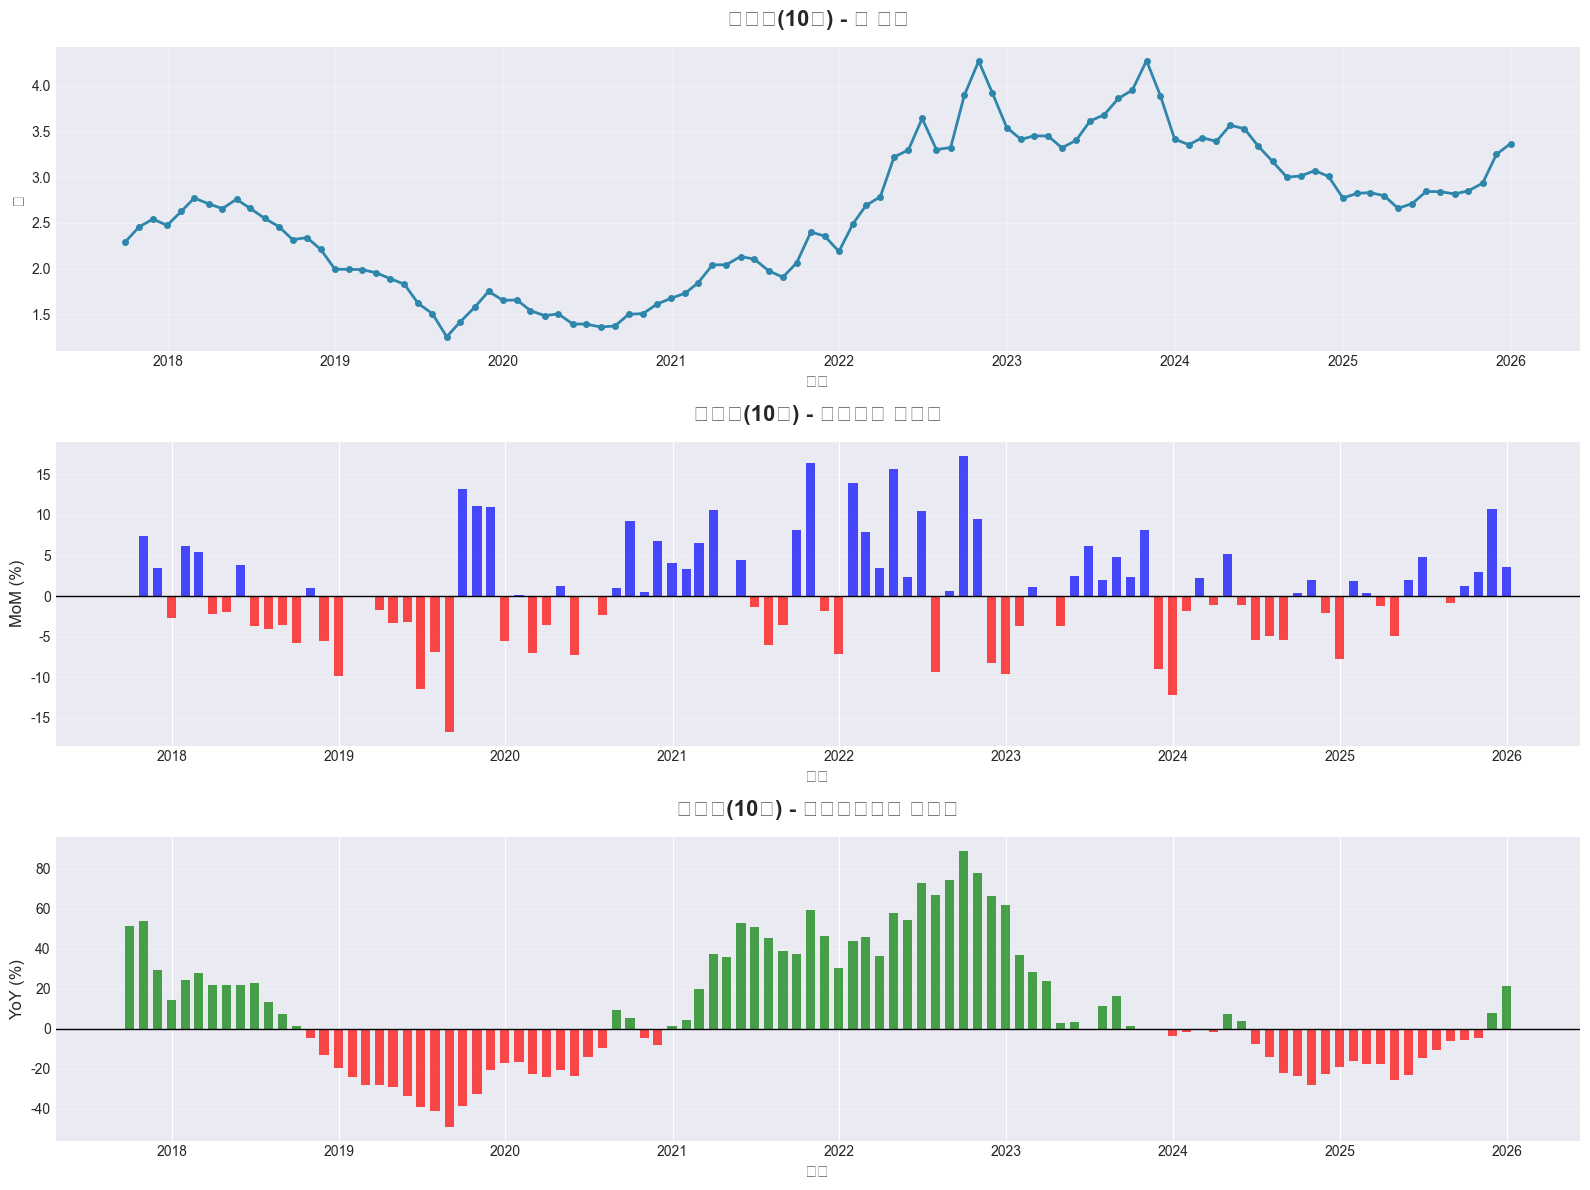

In [19]:
# 특정 지표 시계열 그래프
if len(detail_data) > 0:
    # 날짜 기준으로 정렬
    plot_data = detail_data.sort_values('Date').copy()
    plot_data['Date'] = pd.to_datetime(plot_data['Date'])
    
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    
    # 1. Value 추이
    axes[0].plot(plot_data['Date'], plot_data['Value'], 
                 marker='o', linewidth=2, markersize=4, color='#2E86AB')
    axes[0].set_title(f"{plot_data['Index_Name'].iloc[0]} - 값 추이", 
                      fontsize=16, fontweight='bold', pad=15)
    axes[0].set_xlabel('날짜', fontsize=12)
    axes[0].set_ylabel('값', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(labelsize=10)
    
    # 2. MoM 변화율
    mom_data = plot_data.dropna(subset=['MoM'])
    if len(mom_data) > 0:
        colors_mom = ['red' if x < 0 else 'blue' for x in mom_data['MoM']]
        axes[1].bar(mom_data['Date'], mom_data['MoM'] * 100, 
                    color=colors_mom, alpha=0.7, width=20)
        axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
        axes[1].set_title(f"{plot_data['Index_Name'].iloc[0]} - 전월대비 변화율", 
                          fontsize=16, fontweight='bold', pad=15)
        axes[1].set_xlabel('날짜', fontsize=12)
        axes[1].set_ylabel('MoM (%)', fontsize=12)
        axes[1].grid(True, alpha=0.3, axis='y')
        axes[1].tick_params(labelsize=10)
    
    # 3. YoY 변화율
    yoy_data = plot_data.dropna(subset=['YoY'])
    if len(yoy_data) > 0:
        colors_yoy = ['red' if x < 0 else 'green' for x in yoy_data['YoY']]
        axes[2].bar(yoy_data['Date'], yoy_data['YoY'] * 100, 
                    color=colors_yoy, alpha=0.7, width=20)
        axes[2].axhline(y=0, color='black', linestyle='-', linewidth=1)
        axes[2].set_title(f"{plot_data['Index_Name'].iloc[0]} - 전년동기대비 변화율", 
                          fontsize=16, fontweight='bold', pad=15)
        axes[2].set_xlabel('날짜', fontsize=12)
        axes[2].set_ylabel('YoY (%)', fontsize=12)
        axes[2].grid(True, alpha=0.3, axis='y')
        axes[2].tick_params(labelsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("시각화할 데이터가 없습니다. 위의 셀에서 지표를 선택해주세요.")

## 13. 데이터 내보내기 (선택사항)

In [ ]:
# 결과 데이터를 CSV 파일로 저장
output_filename = f"BOK_Economic_Data_{datetime.now().strftime('%Y%m%d')}.csv"
result_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
print(f"데이터 저장 완료: {output_filename}")
print(f"저장 위치: {os.path.abspath(output_filename)}")

## 14. 연결 종료

In [22]:
# 데이터베이스 연결 종료
engine.dispose()
print("데이터베이스 연결 종료")
print("\n작업 완료!")

데이터베이스 연결 종료

작업 완료!
